<a href="https://colab.research.google.com/github/xidoudou/ai-agents-in-langgraph/blob/main/Lesson_5_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 5: Human in the Loop

Note: This notebook is running in a later version of langgraph that it was filmed with. The later version has a couple of key additions:
- Additional state information is stored to memory and displayed when using `get_state()` or `get_state_history()`.
- State is additionally stored every state transition while previously it was stored at an interrupt or at the end.
These change the command output slightly, but are a useful addtion to the information available.

In [1]:
from dotenv import load_dotenv

_ = load_dotenv()

In [10]:
import os
from google.colab import userdata
os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [4]:
!pip install langchain_openai langchain_community langchain_community langgraph.checkpoint.sqlite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 4.3 MB/s eta 0:00:00


In [11]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.sqlite import SqliteSaver

memory = SqliteSaver.from_conn_string(":memory:")

In [12]:
from uuid import uuid4
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage

"""
In previous examples we've annotated the `messages` state key
with the default `operator.add` or `+` reducer, which always
appends new messages to the end of the existing messages array.

Now, to support replacing existing messages, we annotate the
`messages` key with a customer reducer function, which replaces
messages with the same `id`, and appends them otherwise.
"""
def reduce_messages(left: list[AnyMessage], right: list[AnyMessage]) -> list[AnyMessage]:
    # assign ids to messages that don't have them
    for message in right:
        if not message.id:
            message.id = str(uuid4())
    # merge the new messages with the existing messages
    merged = left.copy()
    for message in right:
        for i, existing in enumerate(merged):
            # replace any existing messages with the same id
            if existing.id == message.id:
                merged[i] = message
                break
        else:
            # append any new messages to the end
            merged.append(message)
    return merged

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], reduce_messages]

In [13]:
tool = TavilySearchResults(max_results=2)

## Manual human approval

In [14]:
class Agent:
    def __init__(self, model, tools, system="", checkpointer=None):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges("llm", self.exists_action, {True: "action", False: END})
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile(
            checkpointer=checkpointer,
            interrupt_before=["action"]
        )
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def exists_action(self, state: AgentState):
        print(state)
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [16]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [17]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""
model = ChatOpenAI(model="gpt-6-astra")
abot = Agent(model, [tool], system=prompt, checkpointer=memory)

In [18]:
messages = [HumanMessage(content="Whats the weather in SF?")]
thread = {"configurable": {"thread_id": "1"}}
for event in abot.graph.stream({"messages": messages}, thread):
    for v in event.values():
        print(v)

{'messages': [HumanMessage(content='Whats the weather in SF?', additional_kwargs={}, response_metadata={}, id='d9db77a6-0a1d-492c-80e8-8fdb95a08e88'), AIMessage(content=[{'arguments': '{"query":"San Francisco weather right now current temperature"}', 'call_id': 'call_l7USc92fyC0TMiGJpn8p3To3', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0456b9954844dd89006ab27e07701487d1addc0b7d7e3e34ab', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0456b9954844dd89006ab27e051f2487d18d60d44526ad1a82', 'created_at': 1790082565.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0456b9954844dd89006ab27e051f2487d18d60d44526ad1a82', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'San Francisco weather right now current temperature'}, 'id': 'call_l7USc92fyC0TMiGJpn8p3To3', 'type': 'tool_call'}], i

In [19]:
abot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in SF?', additional_kwargs={}, response_metadata={}, id='d9db77a6-0a1d-492c-80e8-8fdb95a08e88'), AIMessage(content=[{'arguments': '{"query":"San Francisco weather right now current temperature"}', 'call_id': 'call_l7USc92fyC0TMiGJpn8p3To3', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0456b9954844dd89006ab27e07701487d1addc0b7d7e3e34ab', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0456b9954844dd89006ab27e051f2487d18d60d44526ad1a82', 'created_at': 1790082565.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0456b9954844dd89006ab27e051f2487d18d60d44526ad1a82', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'San Francisco weather right now current temperature'}, 'id': 'call_l7USc92fyC0TMiGJpn8p3To3', 'ty

In [20]:
abot.graph.get_state(thread).next

('action',)

### continue after interrupt

In [21]:
for event in abot.graph.stream(None, thread):
    for v in event.values():
        print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'San Francisco weather right now current temperature'}, 'id': 'call_l7USc92fyC0TMiGJpn8p3To3', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content="[{'title': 'San Francisco weather in September 2026 | California', 'url': 'https://www.weather2travel.com/california/san-francisco/september', 'content': 'weather2travel.com - travel deals for your holiday in the sun\\n\\n Home\\n North America\\n USA\\n California\\n San Francisco\\n Weather in September\\n\\n# San Francisco weather in September 2026\\n\\nExpect  daytime maximum temperatures of 22°C in San Francisco, California in September based on long-term weather averages. There are 9 hours of sunshine per day on average.\\n\\n 22°C max day temperature\\n 9 hours of sunshine per day\\n 2 days with some rainfall\\n 13°C min night temperature\\n 12 hours of daylight per day in September in San Francisco12\\n\\n  12 hours of daylight per day\\n No heat

In [22]:
abot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in SF?', additional_kwargs={}, response_metadata={}, id='d9db77a6-0a1d-492c-80e8-8fdb95a08e88'), AIMessage(content=[{'arguments': '{"query":"San Francisco weather right now current temperature"}', 'call_id': 'call_l7USc92fyC0TMiGJpn8p3To3', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0456b9954844dd89006ab27e07701487d1addc0b7d7e3e34ab', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0456b9954844dd89006ab27e051f2487d18d60d44526ad1a82', 'created_at': 1790082565.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0456b9954844dd89006ab27e051f2487d18d60d44526ad1a82', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'San Francisco weather right now current temperature'}, 'id': 'call_l7USc92fyC0TMiGJpn8p3To3', 'ty

In [23]:
abot.graph.get_state(thread).next

('action',)

In [24]:
messages = [HumanMessage("Whats the weather in LA?")]
thread = {"configurable": {"thread_id": "2"}}
for event in abot.graph.stream({"messages": messages}, thread):
    for v in event.values():
        print(v)
while abot.graph.get_state(thread).next:
    print("\n", abot.graph.get_state(thread),"\n")
    _input = input("proceed?")
    if _input != "y":
        print("aborting")
        break
    for event in abot.graph.stream(None, thread):
        for v in event.values():
            print(v)

{'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='dd40c4e9-270a-49f4-a86b-f71db0853ca6'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_q9NChwt7jFoDJdvntrOAYMZc', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0387d9c1b5447d10006ab27e1c3bfc87d1907f1029c4046f33', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0387d9c1b5447d10006ab27e18cc3087d195385b9322c920d9', 'created_at': 1790082584.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0387d9c1b5447d10006ab27e18cc3087d195385b9322c920d9', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles weather current temperature today'}, 'id': 'call_q9NChwt7jFoDJdvntrOAYMZc', 'type': 'tool_call'}], invalid_tool_

## Modify State
Run until the interrupt and then modify the state.

In [25]:
messages = [HumanMessage("Whats the weather in LA?")]
thread = {"configurable": {"thread_id": "3"}}
for event in abot.graph.stream({"messages": messages}, thread):
    for v in event.values():
        print(v)

{'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles weather current temperature today'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_call'}], invalid_tool_

In [26]:
abot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles weather current temperature today'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_c

In [27]:
current_values = abot.graph.get_state(thread)

In [28]:
current_values.values['messages'][-1]

AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles weather current temperature today'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 153, 'output_tokens': 27, 'total_tokens': 180, 'input_token_details': {'cache_creation': 0, 'cache_read': 0},

In [29]:
current_values.values['messages'][-1].tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Los Angeles weather current temperature today'},
  'id': 'call_goMMSKPr3VzrS26WF1Ski5qO',
  'type': 'tool_call'}]

In [30]:
_id = current_values.values['messages'][-1].tool_calls[0]['id']
current_values.values['messages'][-1].tool_calls = [
    {'name': 'tavily_search_results_json',
  'args': {'query': 'current weather in Louisiana'},
  'id': _id}
]

In [31]:
abot.graph.update_state(thread, current_values.values)

{'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Louisiana'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO'}], invalid_tool_calls=[], usage_metadata={'input_token

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b68b0-fb74-6f11-8002-4eadec137839'}}

In [32]:
abot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Louisiana'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_call'}], invalid_t

In [33]:
for event in abot.graph.stream(None, thread):
    for v in event.values():
        print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Louisiana'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content='[{\'title\': \'Real-Time Louisiana 22 Weather Conditions: Temperature | 30 Days Forecast\', \'url\': \'https://www.aqi.in/weather/us/united-states/louisiana/madisonville/louisiana-22\', \'content\': "4. Will it rain in Louisiana 22 today?\\n\\nAs of 04:00 AM 19 September 2026, there is a 6% chance of rainfall in Louisiana 22 later today around 2026-09-19 04:00. Current precipitation is 0 mm. Residents are advised to carry an umbrella before heading out.\\n\\n5. What is the monthly weather forecast for Louisiana 22 in September 2026?\\n\\nSeptember 2026 in Louisiana 22 is forecast to have 17 sunny days, 10 rainy days, 1 cloudy days, and 0 snowy days. Temperatures for the month range from lows around 21°C to highs of 35°C.\\n\\n6. How does the weather in Louisiana 22 affect air 

## Time Travel

In [34]:
states = []
for state in abot.graph.get_state_history(thread):
    print(state)
    print('--')
    states.append(state)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Louisiana'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_call'}], invalid_t

To fetch the same state as was filmed, the offset below is changed to `-3` from `-1`. This accounts for the initial state `__start__` and the first state that are now stored to state memory with the latest version of software.

In [35]:
to_replay = states[-3]

In [36]:
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles weather current temperature today'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_c

In [37]:
for event in abot.graph.stream(None, to_replay.config):
    for k, v in event.items():
        print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles weather current temperature today'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content="[{'title': 'Highest temperature in Los Angeles on September 22, 2026?', 'url': 'https://www.gemini.com/predictions/WXHIGH-LA-2609230359', 'content': 'NWS point forecast calls for KLAX high near 77°F tomorrow after morning patchy fog. 74-77°F bracket is the read.', 'score': 0.86713725}, {'title': 'HEAT OUT WEST: How high will temps get in Los Angeles ...', 'url': 'https://www.facebook.com/FoxWeather/videos/-heat-out-west-how-high-will-temps-get-in-los-angeles-today-fox-weather-meteorol/1698385218155439', 'content': 'Sep 22, 2026 A … which suggests a high probability of temperatures between 70-71°F at LAX. High humidity and warm overnight', 'score': 0.86632514}]", name='tavily_search_results_json', id='760dfe1f-323d-446d-adce-9a64d0862e7c', tool_call_id='call_go

## Go back in time and edit

In [38]:
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles weather current temperature today'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_c

In [39]:
_id = to_replay.values['messages'][-1].tool_calls[0]['id']
to_replay.values['messages'][-1].tool_calls = [{'name': 'tavily_search_results_json',
  'args': {'query': 'current weather in LA, accuweather'},
  'id': _id}]

In [40]:
branch_state = abot.graph.update_state(to_replay.config, to_replay.values)

{'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in LA, accuweather'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO'}], invalid_tool_calls=[], usage_metadata={'input

In [41]:
for event in abot.graph.stream(None, branch_state):
    for k, v in event.items():
        if k != "__end__":
            print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather in LA, accuweather'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content='[{\'title\': \'Los Angeles International Airport, CA Monthly Weather | AccuWeather\', \'url\': \'https://www.accuweather.com/en/us/los-angeles-international-airport/90045/september-weather/7721_poi\', \'content\': "# Los Angeles International Airport, CA\\n\\nLos Angeles International Airport\\n\\nCalifornia\\n\\n## Around the Globe\\n\\nAround the Globe\\n\\n### Winter Center\\n\\n### Radar & Maps\\n\\n### News & Features\\n\\n### Astronomy\\n\\n### Business\\n\\n### Climate\\n\\n### Health\\n\\n### Recreation\\n\\n### Sports\\n\\n### Travel\\n\\n### Warnings\\n\\n### Data Suite\\n\\n### Forensics\\n\\n### Advertising\\n\\n### Superior Accuracy™\\n\\n### Video\\n\\n### Severe Weather\\n\\n### Hurricane Tracker\\n\\n## Monthly\\n\\n## September\\n\\n## 2026\\n\\n## 10-Da

## Add message to a state at a given time

In [42]:
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in LA, accuweather'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO'}], invalid_tool_calls=[], u

In [43]:
_id = to_replay.values['messages'][-1].tool_calls[0]['id']

In [44]:
state_update = {"messages": [ToolMessage(
    tool_call_id=_id,
    name="tavily_search_results_json",
    content="54 degree celcius",
)]}

In [45]:
branch_and_add = abot.graph.update_state(
    to_replay.config,
    state_update,
    as_node="action")

In [46]:
for event in abot.graph.stream(None, branch_and_add):
    for k, v in event.items():
        print(v)

{'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='948b1713-daeb-48f2-8e8e-bbbed4345dcb'), AIMessage(content=[{'arguments': '{"query":"Los Angeles weather current temperature today"}', 'call_id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'name': 'tavily_search_results_json', 'type': 'function_call', 'id': 'fc_0980f9c990964e59006ab281ce5a9887d196174102518b7d4e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', 'created_at': 1790083532.0, 'metadata': {}, 'model': 'gpt-6-astra', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-6-astra'}, id='resp_0980f9c990964e59006ab281cc481087d18a9743bf6fc9cbb8', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles weather current temperature today'}, 'id': 'call_goMMSKPr3VzrS26WF1Ski5qO', 'type': 'tool_call'}], invalid_tool_

# Extra Practice

## Build a small graph
This is a small simple graph you can tinker with if you want more insight into controlling state memory.

In [47]:
from dotenv import load_dotenv

_ = load_dotenv()

In [48]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langgraph.checkpoint.sqlite import SqliteSaver

Define a simple 2 node graph with the following state:
-`lnode`: last node
-`scratch`: a scratchpad location
-`count` : a counter that is incremented each step

In [49]:
class AgentState(TypedDict):
    lnode: str
    scratch: str
    count: Annotated[int, operator.add]

In [50]:
def node1(state: AgentState):
    print(f"node1, count:{state['count']}")
    return {"lnode": "node_1",
            "count": 1,
           }
def node2(state: AgentState):
    print(f"node2, count:{state['count']}")
    return {"lnode": "node_2",
            "count": 1,
           }

The graph goes N1->N2->N1... but breaks after count reaches 3.

In [51]:
def should_continue(state):
    return state["count"] < 3

In [52]:
builder = StateGraph(AgentState)
builder.add_node("Node1", node1)
builder.add_node("Node2", node2)

builder.add_edge("Node1", "Node2")
builder.add_conditional_edges("Node2",
                              should_continue,
                              {True: "Node1", False: END})
builder.set_entry_point("Node1")

In [54]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

In [53]:
memory = SqliteSaver.from_conn_string(":memory:")
graph = builder.compile(checkpointer=memory)

TypeError: Invalid checkpointer provided. Expected an instance of `BaseCheckpointSaver`, `True`, `False`, or `None`. Received _GeneratorContextManager. Pass a proper saver (e.g., InMemorySaver, AsyncPostgresSaver).

### Run it!
Now, set the thread and run!

In [55]:
thread = {"configurable": {"thread_id": str(1)}}
graph.invoke({"count":0, "scratch":"hi"},thread)

node1, count:0
node2, count:1
node1, count:2
node2, count:3


{'lnode': 'node_2', 'scratch': 'hi', 'count': 4}

### Look at current state

Get the current state. Note the `values` which are the AgentState. Note the `config` and the `thread_ts`. You will be using those to refer to snapshots below.

In [56]:
graph.get_state(thread)

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a40a-6ab7-8004-1b012a0d0a09'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-09-22T13:42:39.296357+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a408-6257-8003-9ba8adf2f31c'}}, tasks=(), interrupts=())

View all the statesnapshots in memory. You can use the displayed `count` agentstate variable to help track what you see. Notice the most recent snapshots are returned by the iterator first. Also note that there is a handy `step` variable in the metadata that counts the number of steps in the graph execution. This is a bit detailed - but you can also notice that the *parent_config* is the *config* of the previous node. At initial startup, additional states are inserted into memory to create a parent. This is something to check when you branch or *time travel* below.

### Look at state history

In [57]:
for state in graph.get_state_history(thread):
    print(state, "\n")

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a40a-6ab7-8004-1b012a0d0a09'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-09-22T13:42:39.296357+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a408-6257-8003-9ba8adf2f31c'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hi', 'count': 3}, next=('Node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a408-6257-8003-9ba8adf2f31c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-09-22T13:42:39.295318+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a406-6bd8-8002-c0678b03dd3d'}}, tasks=(PregelTask(id='74456f74-1e97-5394-2376-ebb79c9f3f3a', name='Node2', path=('__pregel_pull

Store just the `config` into an list. Note the sequence of counts on the right. `get_state_history` returns the most recent snapshots first.

In [58]:
states = []
for state in graph.get_state_history(thread):
    states.append(state.config)
    print(state.config, state.values['count'])

{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a40a-6ab7-8004-1b012a0d0a09'}} 4
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a408-6257-8003-9ba8adf2f31c'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a406-6bd8-8002-c0678b03dd3d'}} 2
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a403-636b-8001-af81bb1ffc61'}} 1
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a400-66bf-8000-11d4b1d88fc6'}} 0
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a3fb-6f74-bfff-ec227b97d371'}} 0


Grab an early state.

In [59]:
states[-3]

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b68b7-a403-636b-8001-af81bb1ffc61'}}

This is the state after Node1 completed for the first time. Note `next` is `Node2`and `count` is 1.

In [60]:
graph.get_state(states[-3])

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hi', 'count': 1}, next=('Node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a403-636b-8001-af81bb1ffc61'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-22T13:42:39.293302+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a400-66bf-8000-11d4b1d88fc6'}}, tasks=(PregelTask(id='d9302eb9-f574-96ed-20ac-0145827c4b27', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result={'lnode': 'node_2', 'count': 1}),), interrupts=())

### Go Back in Time
Use that state in `invoke` to go back in time. Notice it uses states[-3] as *current_state* and continues to node2,

In [61]:
graph.invoke(None, states[-3])

node2, count:1
node1, count:2
node2, count:3


{'lnode': 'node_2', 'scratch': 'hi', 'count': 4}

Notice the new states are now in state history. Notice the counts on the far right.

In [62]:
thread = {"configurable": {"thread_id": str(1)}}
for state in graph.get_state_history(thread):
    print(state.config, state.values['count'])

{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-4710-621c-8005-31fcf1ef1dd3'}} 4
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-470e-62f6-8004-311bbff8630d'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-470a-6e8c-8003-64748a657d01'}} 2
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-4705-6a25-8002-72061578bda4'}} 1
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a40a-6ab7-8004-1b012a0d0a09'}} 4
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a408-6257-8003-9ba8adf2f31c'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a406-6bd8-8002-c0678b03dd3d'}} 2
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b7-a403-636b-8001-af81bb1ffc61'}} 1
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkp

You can see the details below. Lots of text, but try to find the node that start the new branch. Notice the parent *config* is not the previous entry in the stack, but is the entry from state[-3].

In [63]:
thread = {"configurable": {"thread_id": str(1)}}
for state in graph.get_state_history(thread):
    print(state,"\n")

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-4710-621c-8005-31fcf1ef1dd3'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-09-22T13:42:56.390386+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-470e-62f6-8004-311bbff8630d'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hi', 'count': 3}, next=('Node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-470e-62f6-8004-311bbff8630d'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-09-22T13:42:56.389582+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-470a-6e8c-8003-64748a657d01'}}, tasks=(PregelTask(id='490e88a6-441c-adb0-672b-8c0ce4043a5d', name='Node2', path=('__pregel_pull

### Modify State
Let's start by starting a fresh thread and running to clean out history.

In [64]:
thread2 = {"configurable": {"thread_id": str(2)}}
graph.invoke({"count":0, "scratch":"hi"},thread2)

node1, count:0
node2, count:1
node1, count:2
node2, count:3


{'lnode': 'node_2', 'scratch': 'hi', 'count': 4}

In [73]:
!apt-get install -y graphviz graphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-9ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-9ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [76]:
!pip uninstall -y pygraphviz
!pip install pygraphviz

Found existing installation: pygraphviz 2.0.2
Uninstalling pygraphviz-2.0.2:
  Successfully uninstalled pygraphviz-2.0.2
  Using cached pygraphviz-2.0.2-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (3.5 kB)
Using cached pygraphviz-2.0.2-cp313-cp313-manylinux_2_28_x86_64.whl (5.5 MB)


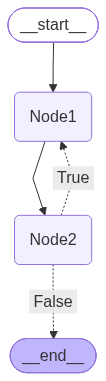

In [78]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [79]:
states2 = []
for state in graph.get_state_history(thread2):
    states2.append(state.config)
    print(state.config, state.values['count'])

{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-8604-6b50-8004-e5697ee99d1d'}} 4
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-85ff-6d35-8003-80b479b41c55'}} 3
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-85fd-679c-8002-9a8289192550'}} 2
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-85f8-6e14-8001-d1be3a54ab83'}} 1
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-85f1-6c0b-8000-fa30a2a4db2a'}} 0
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-85ea-66b7-bfff-f52c4e68fc21'}} 0


Start by grabbing a state.

In [80]:
save_state = graph.get_state(states2[-3])
save_state

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hi', 'count': 1}, next=('Node2',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-85f8-6e14-8001-d1be3a54ab83'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-22T13:43:02.986879+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-85f1-6c0b-8000-fa30a2a4db2a'}}, tasks=(PregelTask(id='4b427417-68da-3d84-7a8b-4ca93e80b885', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result={'lnode': 'node_2', 'count': 1}),), interrupts=())

Now modify the values. One subtle item to note: Recall when agent state was defined, `count` used `operator.add` to indicate that values are *added* to the current value. Here, `-3` will be added to the current count value rather than replace it.

In [81]:
save_state.values["count"] = -3
save_state.values["scratch"] = "hello"
save_state

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': -3}, next=('Node2',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-85f8-6e14-8001-d1be3a54ab83'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-22T13:43:02.986879+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-85f1-6c0b-8000-fa30a2a4db2a'}}, tasks=(PregelTask(id='4b427417-68da-3d84-7a8b-4ca93e80b885', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result={'lnode': 'node_2', 'count': 1}),), interrupts=())

Now update the state. This creates a new entry at the *top*, or *latest* entry in memory. This will become the current state.

In [82]:
graph.update_state(thread2,save_state.values)

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b68c1-3f24-63b4-8005-bf3b45b0dba3'}}

Current state is at the top. You can match the `thread_ts`.
Notice the `parent_config`, `thread_ts` of the new node - it is the previous node.

In [83]:
for i, state in enumerate(graph.get_state_history(thread2)):
    if i >= 3:  #print latest 3
        break
    print(state, '\n')

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': 1}, next=('Node1',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68c1-3f24-63b4-8005-bf3b45b0dba3'}}, metadata={'source': 'update', 'step': 5, 'parents': {}}, created_at='2026-09-22T13:46:57.151668+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-8604-6b50-8004-e5697ee99d1d'}}, tasks=(PregelTask(id='5bc94e9e-19e3-1b98-1eae-ccf8c6fc65c5', name='Node1', path=('__pregel_pull', 'Node1'), error=None, interrupts=(), state=None, result=None),), interrupts=()) 

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68b8-8604-6b50-8004-e5697ee99d1d'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-09-22T13:43:02.991731+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': 

### Try again with `as_node`
When writing using `update_state()`, you want to define to the graph logic which node should be assumed as the writer. What this does is allow th graph logic to find the node on the graph. After writing the values, the `next()` value is computed by travesing the graph using the new state. In this case, the state we have was written by `Node1`. The graph can then compute the next state as being `Node2`. Note that in some graphs, this may involve going through conditional edges!  Let's try this out.

In [84]:
graph.update_state(thread2,save_state.values, as_node="Node1")

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b68c1-7e0e-6cdd-8006-bf2309d06f78'}}

In [85]:
for i, state in enumerate(graph.get_state_history(thread2)):
    if i >= 3:  #print latest 3
        break
    print(state, '\n')

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': -2}, next=('Node2',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68c1-7e0e-6cdd-8006-bf2309d06f78'}}, metadata={'source': 'update', 'step': 6, 'parents': {}}, created_at='2026-09-22T13:47:03.748921+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68c1-3f24-63b4-8005-bf3b45b0dba3'}}, tasks=(PregelTask(id='ad09aab3-b29a-5267-fbd4-92aa0cd4c838', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result=None),), interrupts=()) 

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': 1}, next=('Node1',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68c1-3f24-63b4-8005-bf3b45b0dba3'}}, metadata={'source': 'update', 'step': 5, 'parents': {}}, created_at='2026-09-22T13:46:57.151668+00:00', parent_config={'configurable': {'thread_id': '2', 'ch

`invoke` will run from the current state if not given a particular `thread_ts`. This is now the entry that was just added.

In [86]:
graph.invoke(None,thread2)

node2, count:-2
node1, count:-1
node2, count:0
node1, count:1
node2, count:2


{'lnode': 'node_2', 'scratch': 'hello', 'count': 3}

Print out the state history, notice the `scratch` value change on the latest entries.

In [87]:
for state in graph.get_state_history(thread2):
    print(state,"\n")

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hello', 'count': 3}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68c1-a010-66b3-800b-e7fe729bcb7e'}}, metadata={'source': 'loop', 'step': 11, 'parents': {}}, created_at='2026-09-22T13:47:07.314744+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68c1-a00d-6ba6-800a-55c0cdbdae51'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': 2}, next=('Node2',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68c1-a00d-6ba6-800a-55c0cdbdae51'}}, metadata={'source': 'loop', 'step': 10, 'parents': {}}, created_at='2026-09-22T13:47:07.313639+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b68c1-a00b-63e6-8009-0630a049708b'}}, tasks=(PregelTask(id='65c94b97-5122-589b-dfc4-bdae345691b7', name='Node2', path=('__pre

Continue to experiment!